# ✈️ Airline Passenger Satisfaction Analysis

**Core Question:** What are the key factors driving passenger satisfaction, and do they differ by trip type (business/personal) or travel class?

## 1. Data Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the dataset
df = pd.read_csv('train.csv')

# Drop the redundant index column from the original Excel export
df = df.drop(columns=['Unnamed: 0'])

# 2. Basic inspection
print("--- Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Data Types ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Duplicates ---")
print(df.duplicated().sum())

--- Shape ---
(103904, 24)

--- First 5 Rows ---


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied



--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  str    
 2   Customer Type                      103904 non-null  str    
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  str    
 5   Class                              103904 non-null  str    
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                

### Data Inspection Summary
- Dataset dimensions: 103,904 rows and 24 columns (after dropping the redundant index column).
- Missing values: only 310 missing values in `Arrival Delay in Minutes` (~0.3% of the data) — safe to drop.
- No duplicate rows found.
- Service rating columns (Wifi, Seat comfort, etc.) are on a 0–5 scale.

## 2. Data Cleaning

In [2]:
# Drop rows with missing Arrival Delay (negligible amount, ~0.3%)
df = df.dropna(subset=['Arrival Delay in Minutes'])

# Convert satisfaction to a binary flag for easier aggregation
df['is_satisfied'] = (df['satisfaction'] == 'satisfied').astype(int)

print(f"Final shape after cleaning: {df.shape}")
print(f"Overall satisfaction rate: {df['is_satisfied'].mean():.1%}")

Final shape after cleaning: (103594, 25)
Overall satisfaction rate: 43.3%


## 3. Scoping the Problem: Does Satisfaction Vary by Segment?

C:\Users\Target\AppData\Local\Temp\ipykernel_12384\3808021168.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sat_by_travel.index, y=sat_by_travel.values, ax=axes[0], palette='Blues_d')
C:\Users\Target\AppData\Local\Temp\ipykernel_12384\3808021168.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sat_by_class.index, y=sat_by_class.values, ax=axes[1], palette='Greens_d')


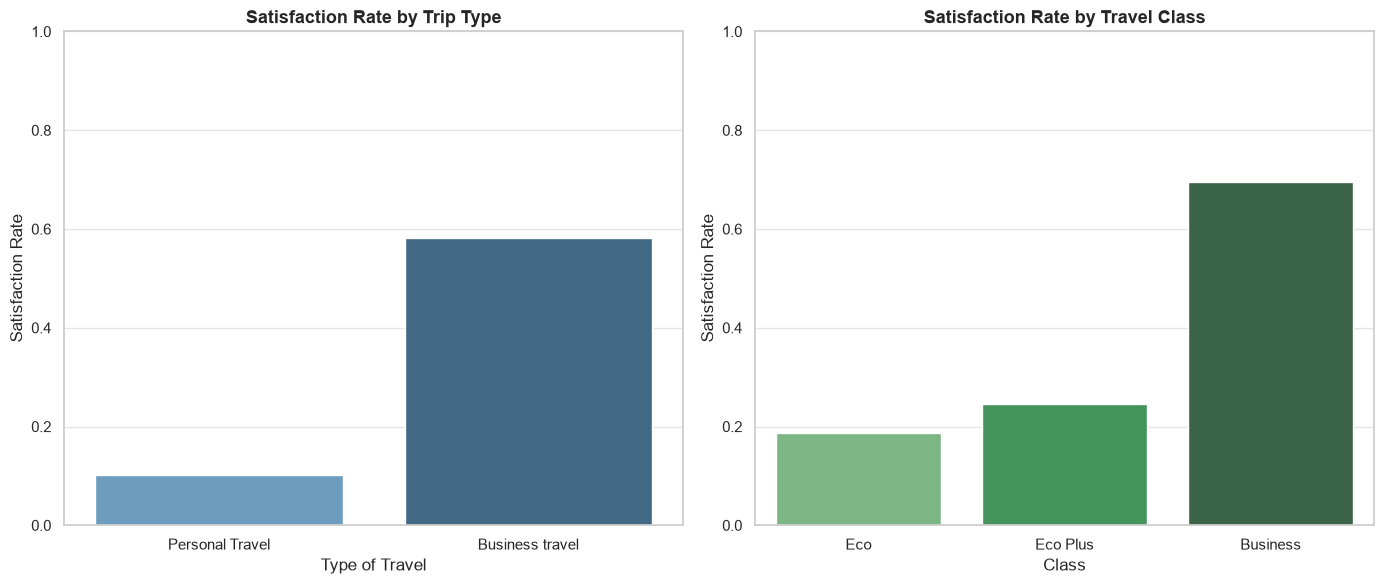

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sat_by_travel = df.groupby('Type of Travel')['is_satisfied'].mean().sort_values()
sns.barplot(x=sat_by_travel.index, y=sat_by_travel.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Satisfaction Rate by Trip Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Satisfaction Rate')
axes[0].set_ylim(0, 1)

sat_by_class = df.groupby('Class')['is_satisfied'].mean().sort_values()
sns.barplot(x=sat_by_class.index, y=sat_by_class.values, ax=axes[1], palette='Greens_d')
axes[1].set_title('Satisfaction Rate by Travel Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Satisfaction Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Key Finding #1: Satisfaction is Driven by *Who's Flying*, Not Just *Service Quality*

- **Business travelers are satisfied 58.3% of the time**, compared to only **10.2% for personal/leisure travelers** — nearly a **6x gap**.
- **Business class passengers are satisfied 69.4% of the time**, vs. **18.6% in Economy** and **24.6% in Economy Plus**.

This is a critical scoping insight: satisfaction isn't uniform across the customer base. Any average satisfaction number (e.g. "just tell us the overall satisfaction rate") would hide this massive gap and mislead decision-making.

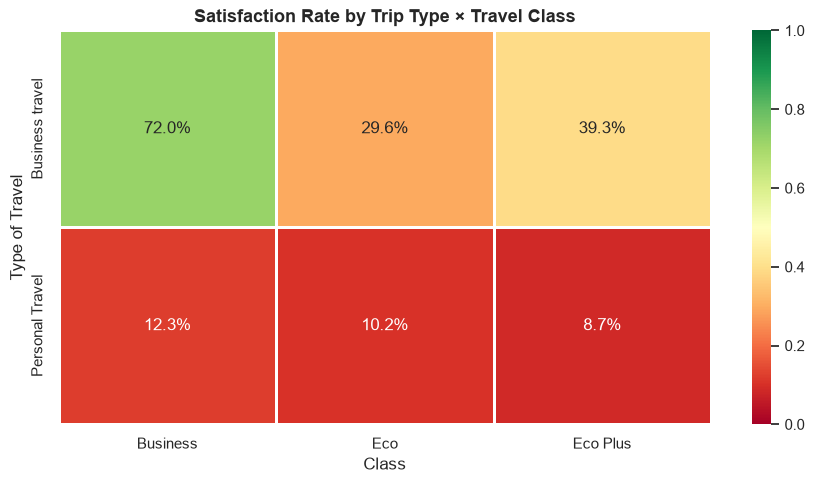

In [4]:
cross = df.groupby(['Type of Travel','Class'])['is_satisfied'].mean().unstack()

plt.figure(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1, linewidths=1)
plt.title('Satisfaction Rate by Trip Type × Travel Class', fontsize=13, fontweight='bold')
plt.ylabel('Type of Travel')
plt.tight_layout()
plt.show()

### Key Finding #2: The Real Gap is "Personal Travel", Regardless of Class

Look closely at the cross-tab: personal travelers are dissatisfied **even in Business class** (12.2% satisfaction) — almost as low as Economy (10.2%). Meanwhile, business travelers stay relatively satisfied even in Economy (29.6%).

**This rules out a simple explanation** ("upgrade personal travelers to Business class and they'll be happy") — the dissatisfaction among personal travelers looks structural, not just about seat class.

## 4. Ruling Out an External Factor: Flight Delays

In [5]:
delay_corr = df[['Departure Delay in Minutes', 'Arrival Delay in Minutes', 'is_satisfied']].corr()['is_satisfied']
print(delay_corr)

Departure Delay in Minutes   -0.050515
Arrival Delay in Minutes     -0.057582
is_satisfied                  1.000000
Name: is_satisfied, dtype: float64


### Key Finding #3: Delays Barely Matter (Correlation ≈ -0.05)

Both departure delay (-0.05) and arrival delay (-0.06) show a **near-zero correlation** with satisfaction. This is counter-intuitive — most people assume delays are the #1 complaint driver — but the data says otherwise.

**Why this matters:** if the airline's leadership assumes "reduce delays → improve satisfaction," this analysis shows that's likely a low-impact lever. Money is better spent elsewhere (see Finding #4).

## 5. Root Cause: Which Service Factors Actually Drive Satisfaction?

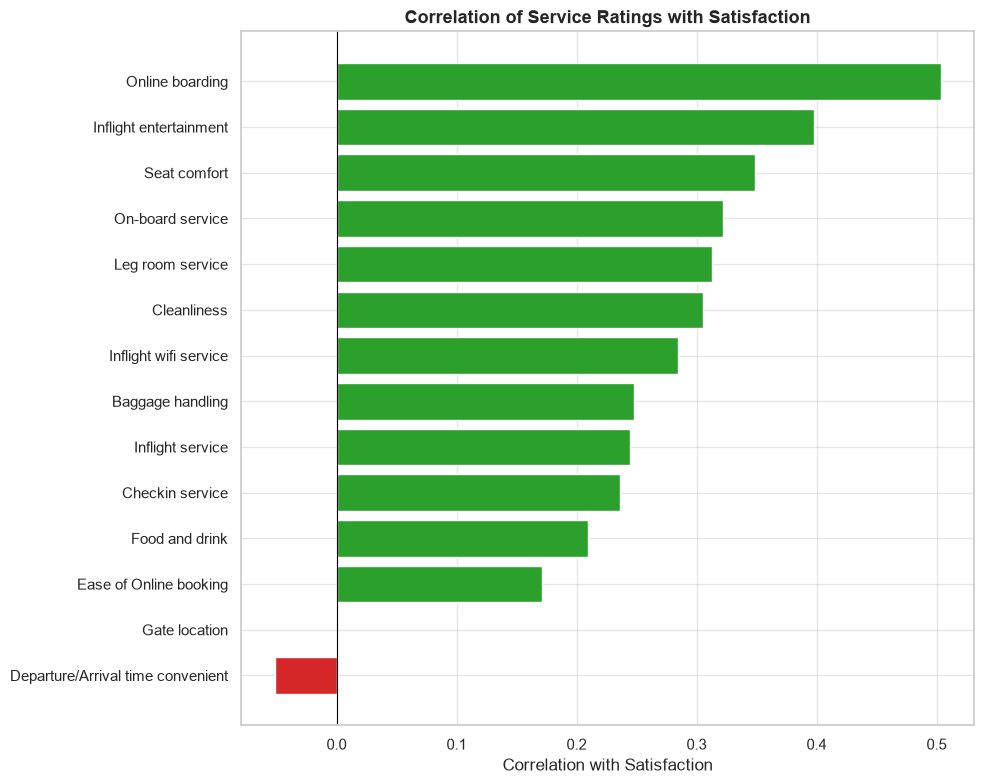

In [6]:
service_cols = ['Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking',
'Gate location','Food and drink','Online boarding','Seat comfort','Inflight entertainment',
'On-board service','Leg room service','Baggage handling','Checkin service','Inflight service','Cleanliness']

corrs = df[service_cols + ['is_satisfied']].corr()['is_satisfied'].drop('is_satisfied').sort_values()

plt.figure(figsize=(10, 8))
colors = ['#d62728' if v < 0.15 else '#2ca02c' for v in corrs.values]
plt.barh(corrs.index, corrs.values, color=colors)
plt.title('Correlation of Service Ratings with Satisfaction', fontsize=13, fontweight='bold')
plt.xlabel('Correlation with Satisfaction')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Key Finding #4: Online Boarding is the #1 Driver — By a Wide Margin

Top 3 service factors correlated with satisfaction:
1. **Online boarding** (0.50) — more than double the next factor
2. **Inflight entertainment** (0.40)
3. **Seat comfort** (0.35)

Weakest factors:
- **Gate location** (~0.00) — essentially no relationship
- **Departure/Arrival time convenient** (-0.05) — slightly negative, negligible
- **Food and drink** (0.21) — surprisingly mid-tier despite being a common complaint area

This confirms Finding #3: operational/logistical factors (delays, gate location, timing) have little to do with satisfaction. The strongest levers are **digital experience (online boarding)** and **in-flight comfort/entertainment**.

## 6. Deeper Look: Online Boarding Ratings by Segment

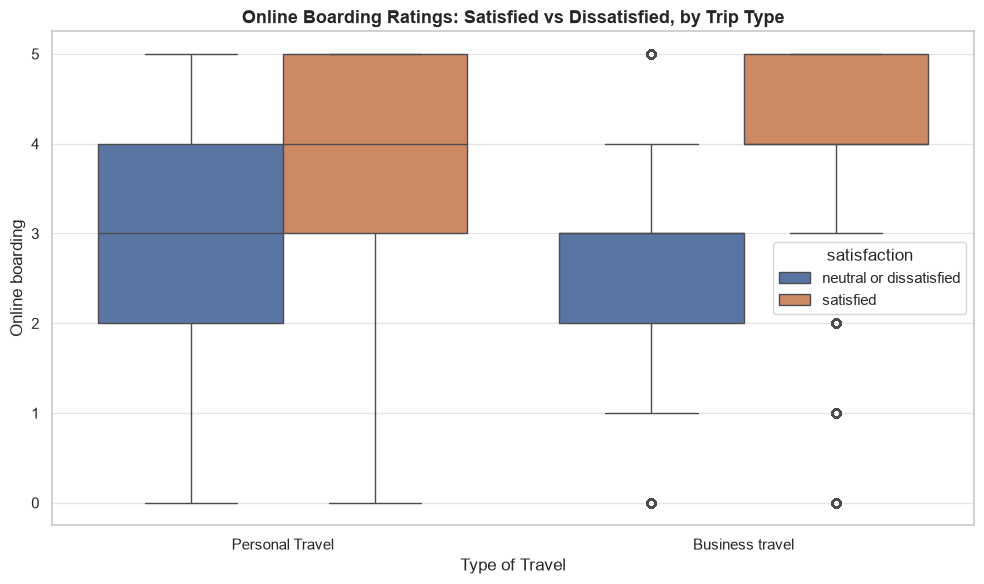

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Type of Travel', y='Online boarding', hue='satisfaction', ax=ax)
ax.set_title('Online Boarding Ratings: Satisfied vs Dissatisfied, by Trip Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Finding #5: The Gap Is Consistent Across Segments

Dissatisfied passengers rate "Online boarding" lower across **both** trip types — this isn't a business-only or personal-only issue. It's a universal lever, meaning fixing it has broad impact rather than helping just one customer segment.

## 7. Summary & Recommendations

### 📌 Headline
**Personal travelers are dissatisfied regardless of class (as low as 12% even in Business), and the strongest satisfaction driver — Online Boarding — matters far more than flight delays (0.50 vs. -0.06 correlation).**

### 🔍 Supporting Evidence
1. Business travelers are satisfied 5.7x more often than personal travelers (58.3% vs 10.2%).
2. Delays (departure & arrival) show almost no correlation with satisfaction (~-0.05), ruling out "reduce delays" as a high-impact fix.
3. Online boarding experience has by far the strongest correlation with satisfaction (0.50) — more than double any other factor.

### ⚠️ Caveats
- This analysis is correlational, not causal — a controlled test (e.g. A/B testing an improved boarding flow) would be needed to confirm the causal impact before large investment.
- The dataset does not indicate the reasons personal travelers are less satisfied (e.g. price sensitivity, expectations) — this requires either survey follow-up questions or qualitative research (exit surveys) to diagnose fully.

### ✅ Recommendation
1. **Invest in improving the online boarding experience** (app/website flow, self-service kiosks) as the highest-leverage fix — expect this to have broader impact than reducing delays.
2. **Investigate the "Personal Travel" segment specifically** — since class upgrades don't fix their dissatisfaction, run a targeted survey to understand root causes (price expectations vs. business travelers, different trip purposes, etc.).
3. **Track success** via: satisfaction rate among personal travelers post-intervention, and the correlation strength of online boarding vs. satisfaction in the next quarter's data.